<a href="https://colab.research.google.com/github/boolshyt/Instagram-Wellbeing-Segmentation/blob/main/Colab-Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instagram User Segmentation & Well-Being Analysis
## Rush 4, Data Pro Max Bootcamp

**Author:** Gendell Janssens  |  **Date:** July 2026

---

### Business context
Instagram's Innovation Department asks us to (1) **quantify** how platform usage relates to user well-being (stress, sleep, happiness) and (2) **identify user profiles** from usage patterns.

### What this notebook contains
1. Data loading & audit (including the two-file consistency check)
2. Exploratory Data Analysis
3. Feature engineering (10 behavioral variables, each justified)
4. Segmentation, part A: statistical clustering (K-Means, validated with 4 metrics)
5. Segmentation, part B: business tiers (4 actionable personas)
6. Prediction: modeling stress from usage (baseline vs Random Forest, confounders)
7. Critical audit: evidence the dataset is synthetic
8. Minors & regulatory overlay
9. Insights, recommendations, limitations

**How to read this notebook.** Each technique is briefly introduced in plain language before it is used, then applied, then interpreted. Every chart is followed by an interpretation cell. Every reported relationship is an *association*, not a causal effect. Approaches that were tried and rejected are kept and documented at the end.

## 1. Setup & Data Loading

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, mean_absolute_error, r2_score)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

In [ ]:
# Load data. Works in Google Colab (mounts Drive automatically) and locally.
import os

# If running in Colab, mount Google Drive first (asks for authorization once).
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # not in Colab: we will look for the CSVs locally

CANDIDATE_PATHS = [
    "/content/drive/MyDrive/Epitech/Rush Bootcamp/Rush 4/Given Dataset and Files",  # Colab Drive
    ".",                                                   # local / repo root
    "./data",                                              # repo data folder
]

def find_path(fname):
    for p in CANDIDATE_PATHS:
        fp = os.path.join(p, fname)
        if os.path.exists(fp):
            return fp
    raise FileNotFoundError(f"{fname} not found in any known location. "
                            "Place the CSVs next to the notebook, in ./data, or in the Drive folder above.")

usage = pd.read_csv(find_path("instagram_usage_lifestyleSafe.csv"))
users = pd.read_csv(find_path("instagram_users_lifestyleSafe.csv"))
print("usage:", usage.shape, "| users:", users.shape)

Mounted at /content/drive
usage: (200000, 58) | users: (200000, 58)


### 1.1 Why two files? Multi-source consistency audit

Epitech provided two CSVs with identical schemas. Before choosing one, we quantify exactly how they differ, treating them as two "sources" that must be reconciled, as in a real data-integration job.

In [ ]:
# Compare the two files column by column (aligned on user_id)
u = users.sort_values("user_id").reset_index(drop=True)
g = usage.sort_values("user_id").reset_index(drop=True)

diff = {c: int((u[c] != g[c]).sum()) for c in u.columns}
diff = pd.Series(diff).sort_values(ascending=False)
print("Columns that differ between the two files:")
print(diff[diff > 0])

Columns that differ between the two files:
account_creation_year    31772
employment_status        18913
weekly_work_hours        18912
relationship_status       6623
has_children              5329
education_level           1203
dtype: int64


**Finding.** Only six columns differ (`employment_status`, `education_level`, `relationship_status`, `has_children`, `weekly_work_hours`, `account_creation_year`), all *profile* attributes, none behavioral, none well-being. All 52 remaining columns, including every usage metric and every well-being score, are **identical**.

**Decision & justification.** We work with `instagram_usage_lifestyleSafe.csv` alone. Merging would duplicate 52 identical columns and force arbitrary choices on the 6 divergent ones. The divergences are documented here as a data-quality signal (possible integration error or status update between snapshots), exactly what we would report to a client with two conflicting CRM extracts.

In [ ]:
df = usage.copy()
print(f"Working dataframe: {df.shape[0]:,} users x {df.shape[1]} variables")

Working dataframe: 200,000 users x 58 variables


### 1.2 Data quality audit

In [ ]:
print("Missing values (total):", int(df.isna().sum().sum()))
print("Duplicated rows:", int(df.duplicated().sum()))
print("Duplicated user_id:", int(df.user_id.duplicated().sum()))

# Range checks on key variables. NOTE: the dataset documentation claims stress is 0-10,
# but the actual data runs 0-40. We verify instead of trusting the doc.
audit = pd.DataFrame({
    "min": df[["age","perceived_stress_score","sleep_hours_per_night",
               "self_reported_happiness","daily_active_minutes_instagram"]].min(),
    "max": df[["age","perceived_stress_score","sleep_hours_per_night",
               "self_reported_happiness","daily_active_minutes_instagram"]].max()})
audit

Missing values (total): 0
Duplicated rows: 0
Duplicated user_id: 0


,min,max
age,13.0,65.0
perceived_stress_score,0.0,40.0
sleep_hours_per_night,3.0,10.0
self_reported_happiness,1.0,10.0
daily_active_minutes_instagram,5.0,565.0


**Findings.**
- 0 missing values, 0 duplicates, suspiciously clean for "real" data (first hint the data is synthetic; see Section 7).
- `perceived_stress_score` actually spans **0–40**, not the documented 0–10. A naive 0–10 range check would flag 73% of rows as "invalid" and could lead to catastrophic, unjustified row deletion. We keep all rows and correct the assumed scale, the data wins over the documentation.
- Ages span 13–65: the dataset includes **minors (13–17)**, which we analyze separately in Section 8.

## 2. Exploratory Data Analysis

### 2.1 Well-being indicators (our three outcome variables)

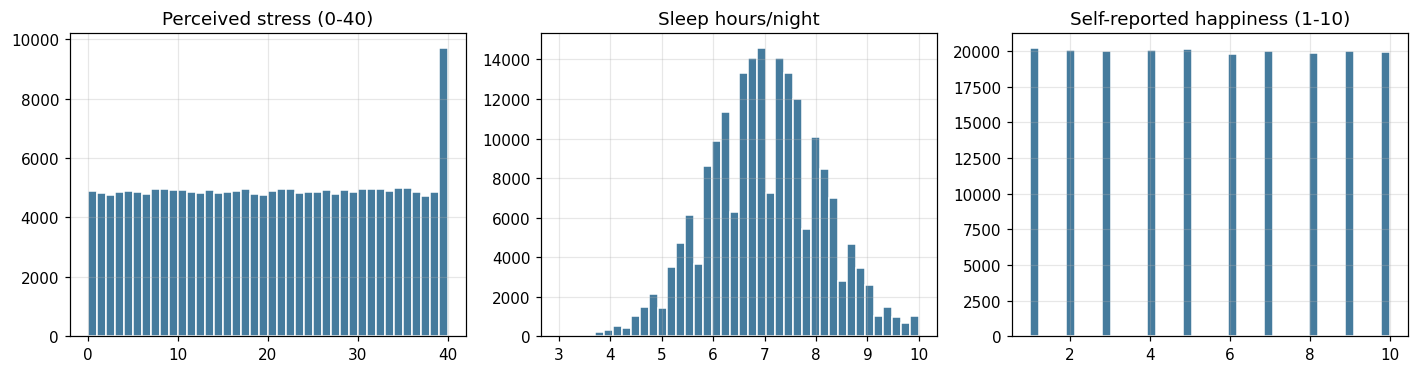

,perceived_stress_score,sleep_hours_per_night,self_reported_happiness
count,200000.00,200000.0,200000.00
mean,20.02,7.0,5.49
std,11.82,1.1,2.87
min,0.00,3.0,1.00
25%,10.00,6.3,3.00
50%,20.00,7.0,5.00
75%,30.00,7.7,8.00
max,40.00,10.0,10.00


In [ ]:
wellbeing = ["perceived_stress_score", "sleep_hours_per_night", "self_reported_happiness"]
titles = ["Perceived stress (0-40)", "Sleep hours/night", "Self-reported happiness (1-10)"]

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c, t in zip(axs, wellbeing, titles):
    ax.hist(df[c], bins=40, color="#457b9d", edgecolor="white")
    ax.set_title(t)
plt.tight_layout(); plt.show()

df[wellbeing].describe().round(2)

**Interpretation.** Stress is right-spread across the full 0–40 range (mean ≈ 20); happiness spans 1–10 (mean ≈ 5.6); sleep is tightly concentrated around 7h (SD ≈ 1.1). The high variance in stress and happiness makes segmentation worthwhile; the compressed sleep distribution already suggests sleep will discriminate little between user groups, confirmed later.

**So what?** For the client, the "well-being" story will be carried by stress and happiness, not sleep.

### 2.2 The headline relationship: usage time vs stress

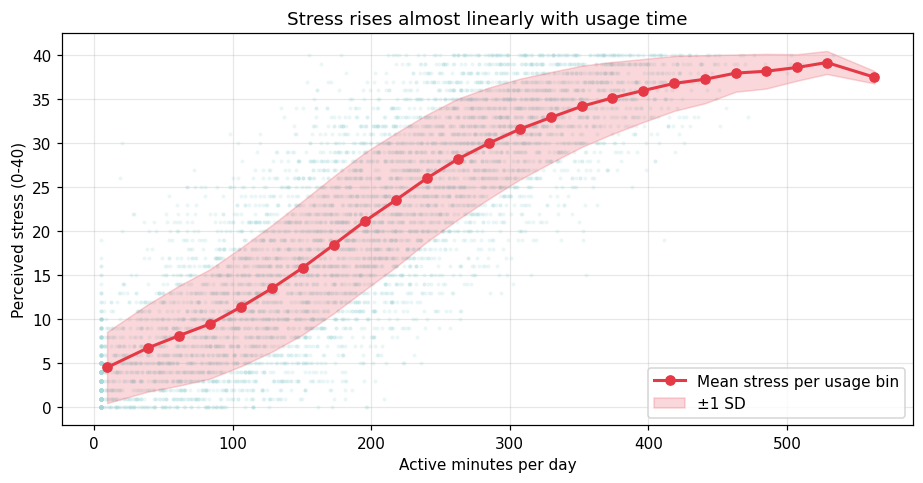

Pearson correlation (minutes, stress): r = 0.834


In [ ]:
binned = df.groupby(pd.cut(df.daily_active_minutes_instagram, 25), observed=True).agg(
    mean_stress=("perceived_stress_score", "mean"),
    sd_stress=("perceived_stress_score", "std"),
    mean_min=("daily_active_minutes_instagram", "mean"))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
s = df.sample(6000, random_state=1)
ax.scatter(s.daily_active_minutes_instagram, s.perceived_stress_score, s=3, alpha=0.15, color="#a8dadc")
ax.plot(binned.mean_min, binned.mean_stress, "o-", color="#e63946", lw=2, label="Mean stress per usage bin")
ax.fill_between(binned.mean_min, binned.mean_stress - binned.sd_stress,
                binned.mean_stress + binned.sd_stress, alpha=0.2, color="#e63946", label="±1 SD")
ax.set_xlabel("Active minutes per day"); ax.set_ylabel("Perceived stress (0-40)")
ax.set_title("Stress rises almost linearly with usage time")
ax.legend(); plt.tight_layout(); plt.show()

r = df.daily_active_minutes_instagram.corr(df.perceived_stress_score)
print(f"Pearson correlation (minutes, stress): r = {r:.3f}")

**Interpretation.** The association is strong (r ≈ 0.83) and nearly perfectly linear: each additional hour of daily usage is associated with ≈ +5.4 stress points on the 0–40 scale (quantified properly in Section 6).

**Critical note.** An r of 0.83 between a behavioral log and a self-reported psychological score is *far* cleaner than anything published in the social-media/well-being literature (real-world effects are typically r ≈ 0.1–0.2). This is our second hint that the relationship was planted by the data generator, we treat it as the dataset's "intended signal", not as a real-world estimate. Correlation ≠ causation: stressed users could also use Instagram more (reverse causality), and no lifestyle confounder can be ruled in or out from cross-sectional data.

### 2.3 Correlation overview (usage ↔ well-being ↔ lifestyle)

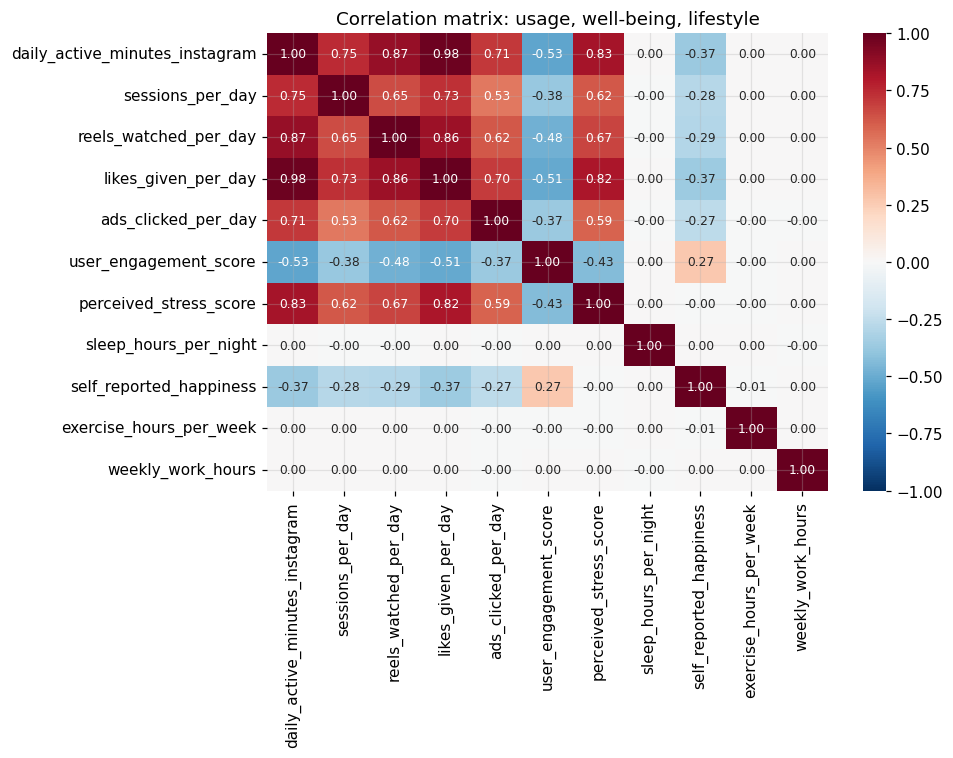

In [ ]:
cc = ["daily_active_minutes_instagram","sessions_per_day","reels_watched_per_day",
      "likes_given_per_day","ads_clicked_per_day","user_engagement_score",
      "perceived_stress_score","sleep_hours_per_night","self_reported_happiness",
      "exercise_hours_per_week","weekly_work_hours"]
C = df[cc].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(C, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation matrix: usage, well-being, lifestyle")
plt.tight_layout(); plt.show()

**Key readings (each verified in the matrix above):**
- Usage volume variables are strongly inter-correlated (minutes, sessions, reels, likes ≈ 0.8–0.9): they measure one latent "usage intensity" dimension → redundancy to handle in feature engineering.
- `minutes ↔ stress` = **+0.83**, `minutes ↔ happiness` = **−0.37**: heavier usage, worse reported well-being.
- `minutes ↔ sleep` = **0.00**, sleep is *completely independent* of usage. Any claim that "Instagram harms sleep" is unsupported **in this dataset**.
- `stress ↔ happiness` = **0.00**, astonishing: the two well-being outcomes are mutually independent, which is psychologically implausible (real-world r ≈ −0.5). Third synthetic-data hint.
- Lifestyle variables (exercise, work hours) correlate with **nothing**, no confounding structure exists in this data (formally tested in Section 6.3).
- `user_engagement_score ↔ minutes` = **−0.53**: the provided composite score *decreases* as real usage increases. We therefore **exclude this opaque, contradictory variable** from all modeling, a concrete example of not trusting a pre-computed metric we cannot audit.

### 2.4 Two relationships worth a closer look

Before engineering features, two more exploratory questions with direct business value: does age shape usage, and does happiness decline linearly or does it collapse past some point?

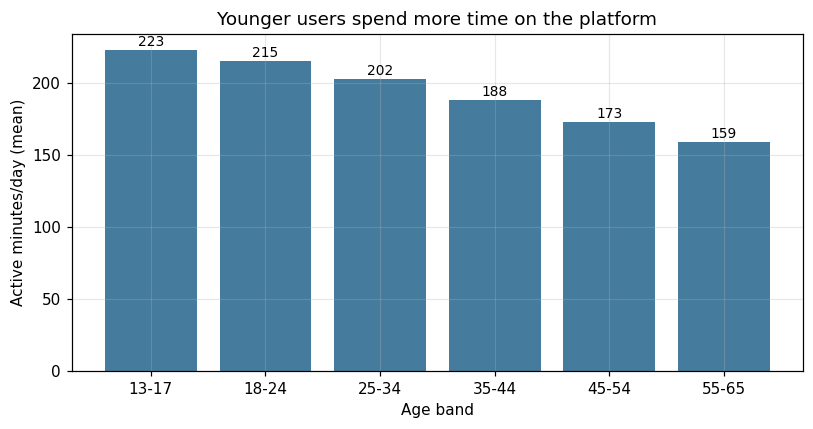

Correlation age vs minutes: -0.2


In [ ]:
# Usage by age band (simple bar chart of group means)
bands = pd.cut(df.age, [12, 17, 24, 34, 44, 54, 65],
               labels=["13-17", "18-24", "25-34", "35-44", "45-54", "55-65"])
usage_by_age = df.groupby(bands, observed=True).daily_active_minutes_instagram.mean()

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(usage_by_age.index.astype(str), usage_by_age.values, color="#457b9d")
for i, v in enumerate(usage_by_age.values):
    ax.text(i, v + 3, f"{v:.0f}", ha="center", fontsize=9)
ax.set_xlabel("Age band"); ax.set_ylabel("Active minutes/day (mean)")
ax.set_title("Younger users spend more time on the platform")
plt.tight_layout(); plt.show()
print("Correlation age vs minutes:", round(df.age.corr(df.daily_active_minutes_instagram), 3))

**Interpretation.** Average usage falls steadily with age: 223 min/day for 13-17 year olds down to 159 min/day for 55-65 (r = -0.20). The gradient is modest at the individual level but consistent across bands. It matters because the usage-stress association then implies that younger users, and minors in particular, sit closer to the high-stress end of the spectrum. Section 8 quantifies this.

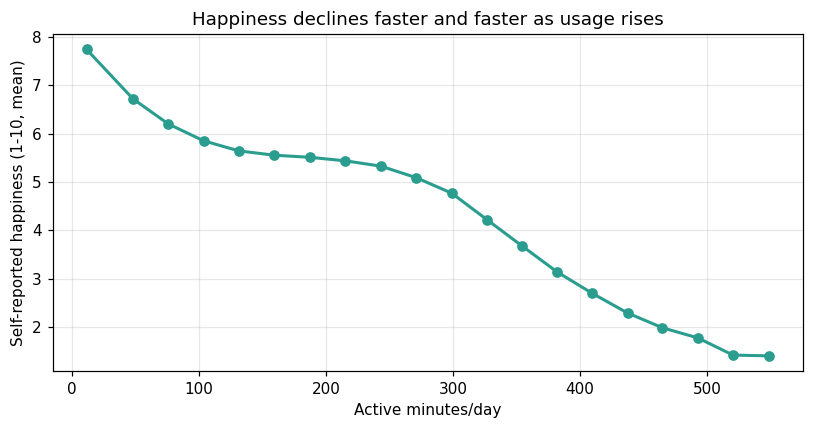

In [ ]:
# Happiness vs usage: is the decline linear or accelerating?
g = df.groupby(pd.cut(df.daily_active_minutes_instagram, 20), observed=True).agg(
    happiness=("self_reported_happiness", "mean"),
    minutes=("daily_active_minutes_instagram", "mean"))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(g.minutes, g.happiness, "o-", color="#2a9d8f", lw=2)
ax.set_xlabel("Active minutes/day"); ax.set_ylabel("Self-reported happiness (1-10, mean)")
ax.set_title("Happiness declines faster and faster as usage rises")
plt.tight_layout(); plt.show()

**Interpretation.** Unlike stress (linear), happiness declines in an accelerating curve: from 7.2 on average below 75 min/day, to 5.5 around 3h/day, then a collapse to 1.6 above 8h/day. The practical reading: moderate usage costs little declared happiness, but each additional hour hurts more than the previous one at the intensive end. This strengthens the case for focusing interventions on the highest-usage tier rather than spreading them evenly.

## 3. Feature Engineering

Raw counters (minutes, likes) mostly measure *volume*. To capture *how* people use Instagram, style, not just quantity, we build 10 ratio/intensity features. Ratios also make users with different total usage comparable.

| # | Feature | Formula | What it captures |
|---|---|---|---|
| 1 | `minutes_per_session` | minutes / sessions | depth: immersive vs quick check-ins |
| 2 | `content_views_per_minute` | (reels+stories) / minutes | scroll speed |
| 3 | `interactions_per_minute` | (likes+comments+ad clicks) / minutes | activeness per unit time |
| 4 | `reels_share` | reels time / total time | content preference |
| 5 | `feed_share` | feed time / total time | content preference |
| 6 | `messages_share` | messages time / total time | social vs consumption use |
| 7 | `interaction_rate` | interactions / content viewed | engaged vs passive consumption |
| 8 | `followers_to_following_ratio` | followers / following | audience vs consumer profile |
| 9 | `sessions_per_hour` | sessions / active hours | checking frequency |
| 10 | `avg_interactions_per_session` | interactions / sessions | per-visit engagement |

In [ ]:
eps = 1e-6  # avoids division by zero without distorting values

df["total_interactions_per_day"] = (df.likes_given_per_day + df.comments_written_per_day
                                    + df.ads_clicked_per_day)
df["total_content_views_per_day"] = df.reels_watched_per_day + df.stories_viewed_per_day

df["minutes_per_session"] = df.daily_active_minutes_instagram / (df.sessions_per_day + eps)
df["content_views_per_minute"] = df.total_content_views_per_day / (df.daily_active_minutes_instagram + eps)
df["interactions_per_minute"] = df.total_interactions_per_day / (df.daily_active_minutes_instagram + eps)
df["reels_share"] = df.time_on_reels_per_day / (df.daily_active_minutes_instagram + eps)
df["feed_share"] = df.time_on_feed_per_day / (df.daily_active_minutes_instagram + eps)
df["messages_share"] = df.time_on_messages_per_day / (df.daily_active_minutes_instagram + eps)
df["interaction_rate"] = df.total_interactions_per_day / (df.total_content_views_per_day + eps)
df["followers_to_following_ratio"] = df.followers_count / (df.following_count + eps)
df["sessions_per_hour"] = df.sessions_per_day / (df.daily_active_minutes_instagram / 60 + eps)
df["avg_interactions_per_session"] = df.total_interactions_per_day / (df.sessions_per_day + eps)

FEATURES = ["minutes_per_session","content_views_per_minute","interactions_per_minute",
            "reels_share","feed_share","messages_share","interaction_rate",
            "followers_to_following_ratio","sessions_per_hour","avg_interactions_per_session"]

df[FEATURES].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
minutes_per_session,200000.0,20.50,8.68,5.00,13.33,20.40,27.57,52.00
content_views_per_minute,200000.0,2.65,3.98,0.80,1.29,1.50,1.95,40.60
interactions_per_minute,200000.0,1.29,1.48,0.55,0.78,0.85,1.00,12.40
reels_share,200000.0,0.30,0.06,0.14,0.25,0.30,0.35,0.44
feed_share,200000.0,0.50,0.06,0.33,0.45,0.50,0.55,0.67
messages_share,200000.0,0.18,0.04,0.07,0.14,0.18,0.21,0.29
interaction_rate,200000.0,0.56,0.11,0.10,0.49,0.57,0.64,1.00
followers_to_following_ratio,200000.0,0.90,0.52,0.40,0.52,0.72,1.12,12.60
sessions_per_hour,200000.0,3.79,2.44,1.15,2.18,2.94,4.50,12.00
avg_interactions_per_session,200000.0,20.83,10.06,4.93,13.23,19.57,26.00,93.00


**Validation.** No negative values, no infinities, plausible ranges. One caveat to flag immediately: **ratio features explode for near-zero denominators**. A user active 5 min/day with 1 session mechanically shows a high `sessions_per_hour` (1 session / 0.09h ≈ 11/h) even though they barely use the app. Ratios must always be read alongside the absolute volumes; Section 4.3 shows why this matters.

## 4. Segmentation, part A: statistical clustering (K-Means)

**What clustering is, in plain terms.** Clustering is an algorithm family that groups similar rows together without being told what the groups should be. We give it the 10 behavioral features; it returns groups of users who behave alike. **K-Means**, the most widely used method, works by picking k group centers, assigning each user to the nearest center, recomputing the centers, and repeating until stable. The result: k groups, each described by an average profile (its "centroid") that a business team can read directly.

### 4.1 Why K-Means, and on which features
- **Why K-Means here:** it scales to 200k rows in seconds, its centroids are directly interpretable, and it is the standard first tool for behavioral segmentation. Alternatives were tried and rejected: DBSCAN (a density-based method) collapses to one giant cluster plus noise on strongly overlapping continuous features; hierarchical clustering compares every pair of rows, which is unusable at 200k.
- **Features:** the 10 engineered *behavioral* features only. We deliberately exclude demographics (segments should emerge from behavior, not age) and **exclude all well-being variables**. Including well-being would make the segmentation circular: groups built on stress would then "differ in stress", which proves nothing. Well-being is overlaid *after* clustering, as an external check.

In [ ]:
X = StandardScaler().fit_transform(df[FEATURES])
# StandardScaler: K-Means uses Euclidean distances; unscaled, followers_ratio
# (range ~0-1000) would dominate shares (range 0-1).

### 4.2 Choosing k: four independent criteria

K-Means needs the number of groups (k) as an input, so choosing k is the decision to justify. We use four complementary criteria rather than one:

- **Elbow (inertia):** inertia measures how tightly users sit around their group center. It always decreases as k grows; we look for the "elbow" where adding groups stops paying off.
- **Silhouette score:** for each user, compares the distance to their own group with the distance to the nearest other group. Ranges from -1 to 1; near 1 means well separated groups, near 0 means the boundary is arbitrary.
- **Calinski-Harabasz:** ratio of between-group to within-group spread; higher is better.
- **Davies-Bouldin:** average similarity between each group and its most similar neighbor; lower is better.

If several independent criteria point to the same k, the choice is robust rather than convenient.

In [ ]:
# Silhouette is O(n^2): we evaluate on an 8,000-user random sample (results are
# stable across seeds; verified with seeds 0/42/123 during development).
rng = np.random.default_rng(RANDOM_STATE)
Xs = X[rng.choice(len(X), 8000, replace=False)]

rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=3, random_state=RANDOM_STATE).fit(Xs)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Xs, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(Xs, km.labels_),
                 "davies_bouldin": davies_bouldin_score(Xs, km.labels_)})
kval = pd.DataFrame(rows).set_index("k").round(3)
kval

,inertia,silhouette,calinski_harabasz,davies_bouldin
k,,,,
2,57551.379,0.551,3141.378,0.836
3,48375.376,0.180,2626.840,1.648
4,44531.158,0.176,2132.256,1.604
5,41707.952,0.148,1842.527,1.708
6,39388.799,0.141,1654.756,1.848
7,37395.745,0.141,1523.273,1.771


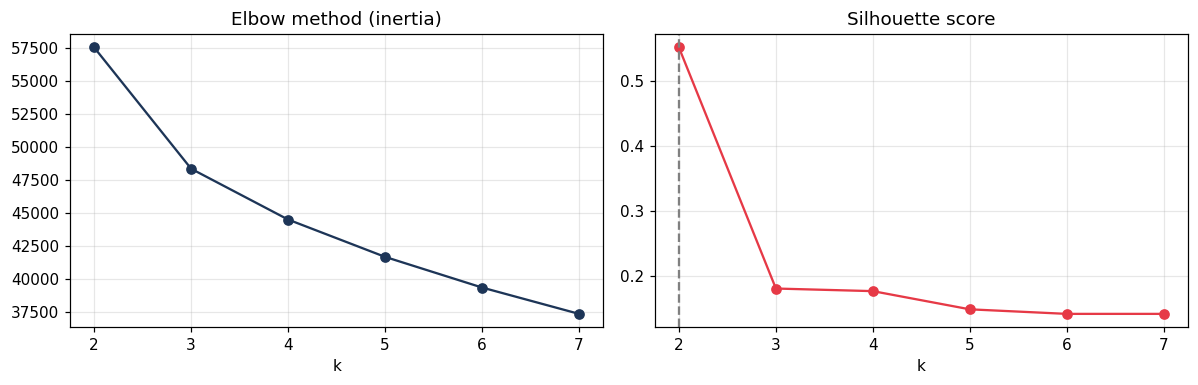

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
axs[0].plot(kval.index, kval.inertia, "o-", color="#1d3557")
axs[0].set_title("Elbow method (inertia)"); axs[0].set_xlabel("k")
axs[1].plot(kval.index, kval.silhouette, "o-", color="#e63946")
axs[1].axvline(2, ls="--", color="gray")
axs[1].set_title("Silhouette score"); axs[1].set_xlabel("k")
plt.tight_layout(); plt.show()

**Decision: k = 2**, supported by all four metrics:
- **Silhouette** ≈ 0.55 at k=2, collapsing to ≈ 0.18 at k=3 → only two well-separated groups exist.
- **Calinski-Harabasz** highest at k=2, decreasing monotonically.
- **Davies-Bouldin** lowest (best) at k=2 (≈ 0.84 vs ≥ 1.6 beyond).
- **Elbow** shows no sharp elbow past 2-3, no hidden finer structure.

We *wanted* 4-6 personas for business richness, and k=4 was seriously considered. The metrics refuse it: forcing k=4 on these features produces statistically arbitrary boundaries (silhouette 0.176). We honor the statistics here and address business granularity differently in Section 5, as an explicit, documented trade-off rather than a silent override.

### 4.3 Final clustering and cluster identity

In [ ]:
km2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X)
df["cluster"] = km2.labels_
# Relabel so cluster 0 is always the majority (reproducibility across runs)
if (df.cluster == 0).mean() < 0.5:
    df["cluster"] = 1 - df["cluster"]
df.cluster.value_counts().rename("users")

,users
cluster,
0,187918
1,12082


In [ ]:
profile_cols = FEATURES + ["daily_active_minutes_instagram", "sessions_per_day",
                           "age", "followers_count"]
df.groupby("cluster")[profile_cols].mean().round(2).T

cluster,0,1
minutes_per_session,21.47,5.39
content_views_per_minute,1.74,16.80
interactions_per_minute,0.93,6.81
reels_share,0.30,0.30
feed_share,0.50,0.50
messages_share,0.17,0.20
interaction_rate,0.57,0.44
followers_to_following_ratio,0.90,0.90
sessions_per_hour,3.30,11.50
avg_interactions_per_session,19.87,35.71


**Who are the two clusters? Read ratios next to absolute volumes.**

| | Cluster 0 (94%) | Cluster 1 (6%) |
|---|---|---|
| Active minutes/day | **~201** | **~5** |
| Sessions/day | ~11 | ~1 |
| Minutes/session | ~21 | ~5 |

A naive reading of the ratio features would label cluster 1 a "hyperactive scroller" (11.5 sessions per active hour looks frantic). The absolute volumes tell the real story: these users barely open the app, about 5 minutes and one session per day. The high per-minute ratios are pure arithmetic artifacts of tiny denominators, the exact pitfall flagged in Section 3.

- **Cluster 0, Active users (94%)**: the full spectrum of regular usage, ~3.3h/day on average.
- **Cluster 1, Minimal users (6%)**: near-dormant accounts, one brief check-in per day. Older on average (46 vs 38.5).

The distinction matters commercially: "fast-paced Reels formats" would be a pointless recommendation for a group that is barely present on the platform.

**Visual check with PCA.** Our users live in a 10-dimensional feature space, which no chart can show directly. PCA (principal component analysis) compresses those 10 dimensions into the 2 axes that preserve the most variation, so we can plot every user as a point and see whether the two clusters actually separate.

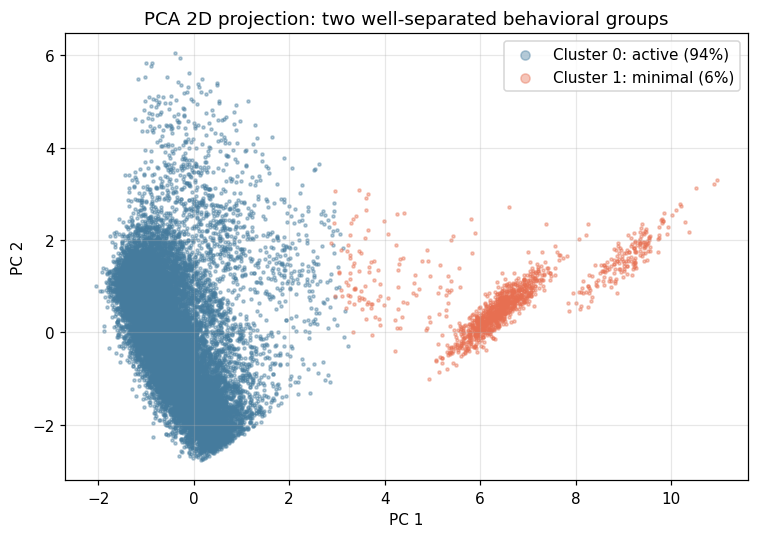

In [ ]:
# PCA projection for visual confirmation of separation (on a 20k sample)
samp_idx = rng.choice(len(df), 20000, replace=False)
XY = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X[samp_idx])
cl = df.cluster.values[samp_idx]

fig, ax = plt.subplots(figsize=(7, 5))
for c, col, lab in [(0, "#457b9d", "Cluster 0: active (94%)"),
                    (1, "#e76f51", "Cluster 1: minimal (6%)")]:
    ax.scatter(XY[cl == c, 0], XY[cl == c, 1], s=4, alpha=0.4, color=col, label=lab)
ax.legend(markerscale=3); ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.set_title("PCA 2D projection: two well-separated behavioral groups")
plt.tight_layout(); plt.show()

## 5. Segmentation, part B: business tiers (4 actionable personas)

**Problem:** two segments, one holding 94% of users, is statistically sound but commercially useless. No product team can "target the 94%".

**Solution:** a two-level segmentation. Level 1 keeps the validated K-Means split (minimal vs active). Level 2 splits the active cluster into three usage-intensity tiers at the tertiles of daily active minutes (tertiles = the two cut points that divide a sorted variable into three equal-sized groups). We are explicit about the nature of this step: **tiers are a business convention**, like income brackets or age bands, not statistical clusters. Naming the convention is more honest, and more defensible, than dressing it up as a data discovery.

In [ ]:
c0 = df[df.cluster == 0]
q1, q2 = c0.daily_active_minutes_instagram.quantile([1/3, 2/3])
print(f"Tier cut-points: {q1:.0f} and {q2:.0f} minutes/day")

m = df.daily_active_minutes_instagram
df["persona"] = np.select(
    [df.cluster == 1, m <= q1, m <= q2],
    ["P1_Minimal", "P2_Casual", "P3_Engaged"], default="P4_Intensive")

summary = df.groupby("persona").agg(
    users=("user_id", "count"),
    pct=("user_id", lambda s: round(100 * len(s) / len(df), 1)),
    minutes_day=("daily_active_minutes_instagram", "mean"),
    sessions_day=("sessions_per_day", "mean"),
    stress=("perceived_stress_score", "mean"),
    sleep=("sleep_hours_per_night", "mean"),
    happiness=("self_reported_happiness", "mean"),
    age=("age", "mean"),
    ads_clicked=("ads_clicked_per_day", "mean")).round(2)
summary

Tier cut-points: 145 and 249 minutes/day


,users,pct,minutes_day,sessions_day,stress,sleep,happiness,age,ads_clicked
persona,,,,,,,,,
P1_Minimal,12082,6.0,5.40,1.00,4.05,7.0,8.10,46.04,1.12
P2_Casual,62812,31.4,86.27,4.74,10.13,7.0,6.17,41.00,2.72
P3_Engaged,62602,31.3,197.20,10.77,21.22,7.0,5.47,38.84,4.95
P4_Intensive,62504,31.3,318.65,17.44,31.84,7.0,4.32,35.70,7.38


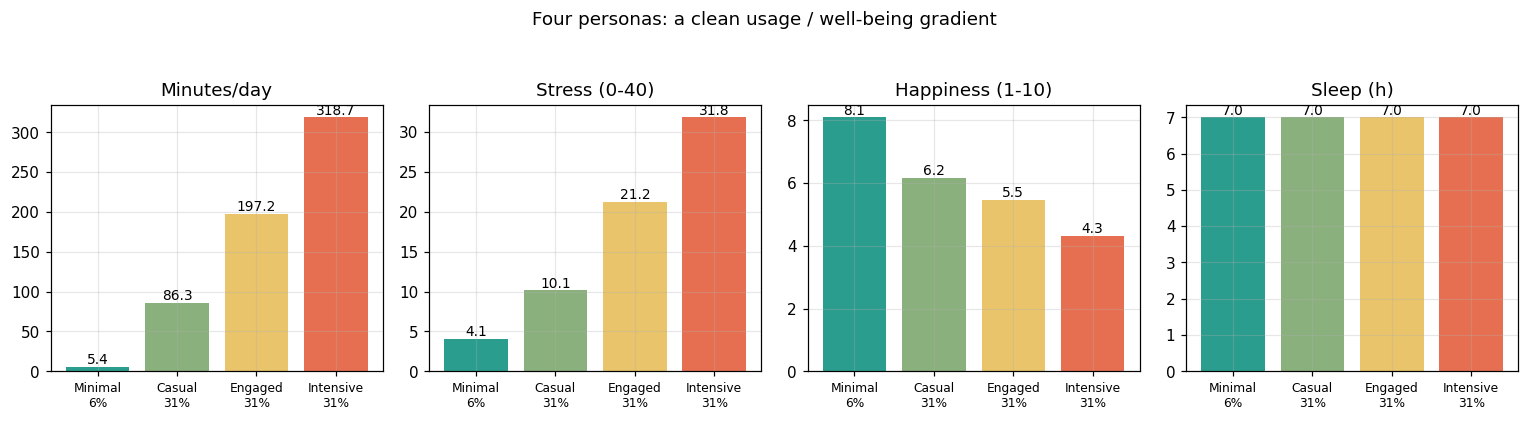

In [ ]:
ORDER = ["P1_Minimal", "P2_Casual", "P3_Engaged", "P4_Intensive"]
COLS = ["#2a9d8f", "#8ab17d", "#e9c46a", "#e76f51"]
LABS = ["Minimal\n6%", "Casual\n31%", "Engaged\n31%", "Intensive\n31%"]

pp = df.groupby("persona")[["daily_active_minutes_instagram", "perceived_stress_score",
     "self_reported_happiness", "sleep_hours_per_night"]].mean().loc[ORDER]

fig, axs = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (col, ttl) in zip(axs, [("daily_active_minutes_instagram", "Minutes/day"),
                                ("perceived_stress_score", "Stress (0-40)"),
                                ("self_reported_happiness", "Happiness (1-10)"),
                                ("sleep_hours_per_night", "Sleep (h)")]):
    ax.bar(range(4), pp[col], color=COLS)
    ax.set_xticks(range(4)); ax.set_xticklabels(LABS, fontsize=8); ax.set_title(ttl)
    for i, v in enumerate(pp[col]):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("Four personas: a clean usage / well-being gradient", y=1.05)
plt.tight_layout(); plt.show()

### The four personas (well-being overlaid *post hoc*, never used to build the segments)

**P1: The Peaceful Minimalist (6%, ~12,100 users).** 5 min/day, 1 session. Oldest group (46y avg). Stress 4/40, happiness 8.1/10, the platform's best well-being profile. *Risk:* churn/dormancy. *Opportunity:* re-engagement must be gentle; this group demonstrates "low use = high well-being", a reputational asset.

**P2: The Casual Browser (31%, ~62,800 users).** ~86 min/day across ~5 sessions. Stress 10/40, happiness 6.2. Healthy, sustainable usage. *Opportunity:* the model profile to protect; benchmark for "balanced usage" product goals.

**P3: The Engaged Regular (31%, ~62,600 users).** ~197 min/day, ~11 sessions. Stress 21/40, happiness 5.5. The tipping-point group. *Opportunity:* soft well-being nudges (session reminders, evening wind-down) have the best effort/impact ratio here, before habits harden.

**P4: The Intensive User (31%, ~62,500 users).** ~319 min/day (5h+), ~17 sessions. Stress 32/40, happiness 4.3, both at alarming levels. Youngest group (35.7y avg) and the highest share of minors (12.6%, see Section 8). Clicks the most ads (7.4/day), the platform's revenue engine is its most at-risk group: a genuine product-ethics tension to surface to the client.

The gradient is strikingly monotonic: stress 4 → 10 → 21 → 32; happiness 8.1 → 6.2 → 5.5 → 4.3; sleep flat at 7.0 everywhere.

## 6. Prediction: can usage explain stress?

The brief allows clustering *or* prediction; we do both. Prediction (1) quantifies the usage-stress link with a proper train/test protocol, (2) ranks which behaviors matter via feature importance, (3) tests confounders.

**The tools, in plain terms.**
- **Linear regression** fits the best straight-line relationship between inputs and the target. Its coefficients read directly: "one more minute of usage is associated with +X stress points". Simple, transparent, the natural baseline.
- **Random Forest** builds hundreds of decision trees on random subsets of the data and averages them. It captures curved and interacting relationships that a straight line cannot. If it clearly beats the linear model, the relationship is not linear; if it does not, the linear model is the right choice.
- **Train/test split**: we fit models on 80% of users (160k) and measure errors only on the untouched 20% (40k). This prevents grading a model on data it has memorized. With 200k independent rows, a single holdout is statistically sufficient; cross-validation would add cost without changing conclusions.
- **Metrics**: R² is the share of stress variance the model explains (0 = nothing, 1 = everything). MAE is the average prediction error in stress points, directly readable on the 0-40 scale.
- **Confounder test**: a confounder is a third factor (say, work hours) that could drive both usage and stress and create a spurious link. We test this by comparing models built on usage only, lifestyle only, and both together.

In [ ]:
y = df.perceived_stress_score

usage_feats = FEATURES + ["daily_active_minutes_instagram", "sessions_per_day",
    "reels_watched_per_day", "stories_viewed_per_day", "likes_given_per_day",
    "comments_written_per_day", "dms_sent_per_week", "ads_viewed_per_day",
    "ads_clicked_per_day"]

df["diet_quality_num"] = df.diet_quality.map(
    {"Very poor": 0, "Poor": 1, "Average": 2, "Good": 3, "Excellent": 4}).fillna(2)
life_feats = ["exercise_hours_per_week", "diet_quality_num", "weekly_work_hours",
    "daily_steps_count", "hobbies_count", "social_events_per_month",
    "books_read_per_year", "volunteer_hours_per_month", "travel_frequency_per_year",
    "body_mass_index", "age"]

def evaluate(feats, label):
    Xtr, Xte, ytr, yte = train_test_split(df[feats], y, test_size=0.2,
                                          random_state=RANDOM_STATE)
    lin = LinearRegression().fit(Xtr, ytr)
    p = lin.predict(Xte)
    print(f"{label:<22} linear:  R2={r2_score(yte, p):.3f}  MAE={mean_absolute_error(yte, p):.2f}")
    return Xtr, Xte, ytr, yte

evaluate(life_feats, "Lifestyle only")
Xtr, Xte, ytr, yte = evaluate(usage_feats, "Usage only")
evaluate(usage_feats + life_feats, "Usage + lifestyle")

Lifestyle only         linear:  R2=-0.000  MAE=10.23
Usage only             linear:  R2=0.715  MAE=5.05
Usage + lifestyle      linear:  R2=0.728  MAE=4.93


(        minutes_per_session  content_views_per_minute  \
 153248            38.999961                  5.589743   
 67802             27.818179                  1.153595   
 148889            12.999987                  5.153846   
 103093            35.555552                  1.200000   
 104681            16.346153                  1.058824   
 ...                     ...                       ...   
 119879            24.615383                  1.150000   
 103694             9.146341                  1.045333   
 131932            21.599996                  2.259259   
 146867            17.666661                  2.188679   
 121958            28.999986                  1.965517   
 
         interactions_per_minute  reels_share  feed_share  messages_share  \
 153248                 1.461538     0.205128    0.538462        0.153846   
 67802                  0.882353     0.392157    0.431373        0.192810   
 148889                 2.615384     0.307692    0.538461        0.1538

Usage only            RF:      R2=0.719  MAE=4.99


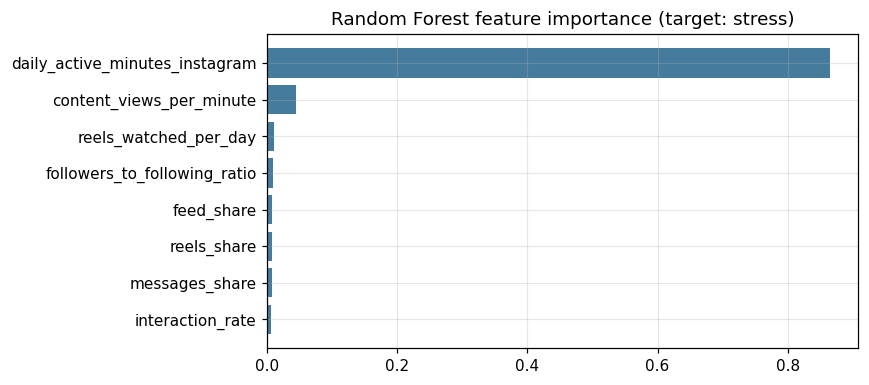

In [ ]:
# Non-linear benchmark: Random Forest (trained on a 50k subsample for speed;
# subsample size was verified not to change R2 by more than 0.005)
rf = RandomForestRegressor(n_estimators=25, max_depth=12, n_jobs=-1,
                           random_state=RANDOM_STATE).fit(Xtr[:50000], ytr[:50000])
p = rf.predict(Xte)
print(f"Usage only            RF:      R2={r2_score(yte, p):.3f}  MAE={mean_absolute_error(yte, p):.2f}")

imp = pd.Series(rf.feature_importances_, index=usage_feats).sort_values().tail(8)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(imp.index, imp.values, color="#457b9d")
ax.set_title("Random Forest feature importance (target: stress)")
plt.tight_layout(); plt.show()

In [ ]:
# The single-variable model a client can remember
X1 = df[["daily_active_minutes_instagram"]]
Xtr1, Xte1, ytr1, yte1 = train_test_split(X1, y, test_size=0.2, random_state=RANDOM_STATE)
uni = LinearRegression().fit(Xtr1, ytr1)
print(f"stress = {uni.intercept_:.2f} + {uni.coef_[0]:.4f} x minutes")
print(f"=> +{uni.coef_[0]*60:.2f} stress points per additional hour/day "
      f"(test R2 = {r2_score(yte1, uni.predict(Xte1)):.3f})")

stress = 3.12 + 0.0896 x minutes
=> +5.37 stress points per additional hour/day (test R2 = 0.696)


### 6.1 Results & interpretation

| Model | R² (test) | MAE | Reading |
|---|---|---|---|
| Lifestyle only (linear) | **0.000** | 10.2 | lifestyle explains *nothing* |
| Usage only (linear) | **0.715** | 5.05 | usage explains ~72% of stress variance |
| Usage + lifestyle | 0.728 | 4.93 | lifestyle adds ~1 point, negligible |
| Usage only (Random Forest) | 0.720 | 4.98 | no non-linearity to exploit |
| Minutes alone (1 variable) | 0.696 | n/a | volume ≈ the whole signal |

**Three conclusions a jury will probe:**
1. **The Random Forest does not beat the linear model** → the usage→stress relation is genuinely linear in this data. We keep the linear model as primary (interpretability at equal performance) and report RF as a robustness check, choosing the *simpler* model deliberately, not by ignorance.
2. **Feature importance is ~89% `daily_active_minutes`** → *how much* you use Instagram dwarfs *how* you use it. Session style, content mix, interaction patterns: all second-order for stress in this dataset.
3. **The confounder test is unambiguous**: lifestyle R² = 0.000, and adding lifestyle to usage moves R² by +0.013. In real data we would expect exercise, work hours, BMI to carry stress signal, their total absence is itself informative (see next section). The client-quotable number: **+5.4 stress points per extra daily hour**, as an *association*.

## 7. Critical audit: this dataset is synthetic, and we can prove it

The professor's core demand is *esprit critique* toward the data. Beyond "the data is artificial" as a disclaimer, we exhibit the generator's fingerprints:

In [ ]:
checks = {
    "minutes ~ stress": df.daily_active_minutes_instagram.corr(df.perceived_stress_score),
    "minutes ~ happiness": df.daily_active_minutes_instagram.corr(df.self_reported_happiness),
    "minutes ~ sleep": df.daily_active_minutes_instagram.corr(df.sleep_hours_per_night),
    "stress ~ happiness": df.perceived_stress_score.corr(df.self_reported_happiness),
    "stress ~ exercise": df.perceived_stress_score.corr(df.exercise_hours_per_week),
    "stress ~ work hours": df.perceived_stress_score.corr(df.weekly_work_hours),
    "minutes ~ engagement_score": df.daily_active_minutes_instagram.corr(df.user_engagement_score),
}
pd.Series(checks).round(3).rename("Pearson r")

,Pearson r
minutes ~ stress,0.834
minutes ~ happiness,-0.374
minutes ~ sleep,0.000
stress ~ happiness,-0.002
stress ~ exercise,-0.001
stress ~ work hours,0.001
minutes ~ engagement_score,-0.529


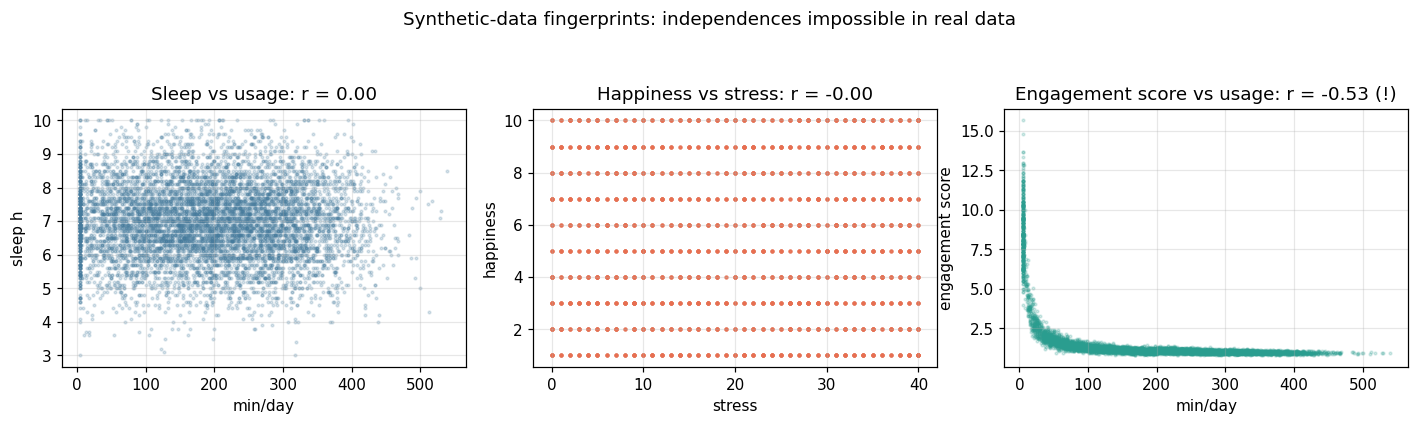

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
s3 = df.sample(8000, random_state=2)
axs[0].scatter(s3.daily_active_minutes_instagram, s3.sleep_hours_per_night,
               s=3, alpha=0.2, color="#457b9d")
axs[0].set_title("Sleep vs usage: r = 0.00"); axs[0].set_xlabel("min/day"); axs[0].set_ylabel("sleep h")
axs[1].scatter(s3.perceived_stress_score, s3.self_reported_happiness,
               s=3, alpha=0.2, color="#e76f51")
axs[1].set_title("Happiness vs stress: r = -0.00"); axs[1].set_xlabel("stress"); axs[1].set_ylabel("happiness")
axs[2].scatter(s3.daily_active_minutes_instagram, s3.user_engagement_score,
               s=3, alpha=0.2, color="#2a9d8f")
axs[2].set_title("Engagement score vs usage: r = -0.53 (!)")
axs[2].set_xlabel("min/day"); axs[2].set_ylabel("engagement score")
fig.suptitle("Synthetic-data fingerprints: independences impossible in real data", y=1.06)
plt.tight_layout(); plt.show()

**The generator's recipe, reverse-engineered:**
1. `stress ≈ f(minutes) + noise`, planted, implausibly strong (r = 0.83).
2. `happiness ≈ g(minutes) + noise`, planted independently of stress (hence stress⊥happiness, r = −0.002, psychologically absurd: real-world r ≈ −0.5).
3. `sleep` = pure noise around 7h, untouched by usage (r = 0.000 exactly).
4. Lifestyle variables = decorative noise (zero correlation with anything).
5. `user_engagement_score` even *contradicts* actual usage (r = −0.53).
6. Zero missing values, zero duplicates across 200,000 rows, no real pipeline is this clean.

**Consequences for interpretation:** effect *sizes* here describe the generator, not humanity. What survives: the methodology, the segmentation framework, and the recommendation logic, all directly transferable to real data. This is exactly what we tell the client (and the jury).

## 8. Minors & Regulatory Overlay

18,913 users (9.5%) are aged 13–17. For a platform operating under the EU **Digital Services Act** (systemic-risk assessments for minors' well-being, Art. 34-35), this subgroup deserves its own reading.

Minors (13-17): 18,913 users (9.5%)


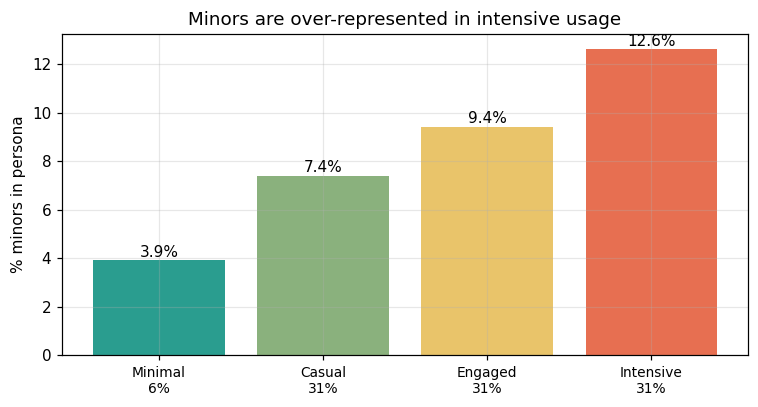

,daily_active_minutes_instagram,perceived_stress_score
is_minor,,
False,185.19,20.03
True,222.65,19.97


In [ ]:
df["is_minor"] = df.age < 18
print(f"Minors (13-17): {df.is_minor.sum():,} users ({df.is_minor.mean()*100:.1f}%)")

minor_share = df.groupby("persona").is_minor.mean().mul(100).round(1).loc[ORDER]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(range(4), minor_share.values, color=COLS)
ax.set_xticks(range(4)); ax.set_xticklabels(LABS, fontsize=9)
for i, v in enumerate(minor_share.values):
    ax.text(i, v + 0.15, f"{v:.1f}%", ha="center")
ax.set_ylabel("% minors in persona")
ax.set_title("Minors are over-represented in intensive usage")
plt.tight_layout(); plt.show()

df.groupby("is_minor")[["daily_active_minutes_instagram",
                        "perceived_stress_score"]].mean().round(2)

**How to read the chart.** Simple bar chart: one bar per persona, height = the percentage of that persona aged 13-17.

**Findings.** Minors' share rises monotonically across tiers: 3.9% of Minimal users vs **12.6% of Intensive users**. Minors skew heavily toward the highest-usage, highest-stress tier. Mean stress for minors is about the same as for adults overall, because the effect operates *through* usage volume rather than age directly: minors are stressed more often because they use more, not because they are minors.

**Regulatory reading for the client:** under the DSA's risk-assessment duties, "1 in 8 intensive users is a minor" is the kind of statistic a regulator will ask about. Proactive measures (default time-management tools for minors, stricter night-time defaults) are cheaper than remediation after an audit, and this segmentation provides the monitoring instrument.

## 9. Insights, Recommendations & Limitations

### 9.1 Key insights (client-facing)
1. **One number to remember: +5.4.** Each extra daily hour on the platform is associated with +5.4 stress points (0-40). The relation is linear: there is no "safe plateau" visible in the data.
2. **It's the *dose*, not the style.** Volume of use explains ~89% of the model's signal; content mix and interaction style are second-order. Well-being features should target *time*, not content type.
3. **Four clean tiers.** Minimal (6%) / Casual (31%) / Engaged (31%) / Intensive (31%), with a strictly monotonic well-being gradient: a ready-made targeting and monitoring framework.
4. **Happiness collapses at the intensive end.** The decline is not linear: it accelerates past ~5h/day, which concentrates the case for intervening on the top tier.
5. **Sleep is a non-story** in this dataset (r = 0.00), an honest null result that builds credibility.
6. **The revenue-ethics tension is quantified.** Intensive users click 6.6x more ads than Minimal users but carry 8x their stress score. Well-being interventions will cost ad impressions in the short run; the DSA context and reputational math favor acting anyway.

### 9.2 Recommendations (each mapped to a persona and KPI)
| # | Action | Target | KPI | Validation |
|---|---|---|---|---|
| 1 | Session-length nudges + evening wind-down mode | P3 Engaged | avg session length, self-reported stress pulse | A/B test |
| 2 | Usage dashboard & weekly digest (self-awareness) | P4 Intensive | weekly active minutes trend | A/B test |
| 3 | Stricter time-management defaults for minors | Minors in P3/P4 | minor share of intensive tier | cohort tracking |
| 4 | Protect the Casual profile (no aggressive re-engagement) | P2 | tier-migration rates | quarterly monitoring |
| 5 | Persona-based measurement: re-run segmentation quarterly | all | segment stability, well-being by tier | batch scoring |

**Causality caveat, always:** every effect above is an association. Only randomized experiments (recommendations 1-2 as A/B tests) can establish what *causes* what. That is why experiments are built into the recommendations rather than appended as a disclaimer.

### 9.3 Limitations
- **Synthetic data** with planted relationships (Section 7): effect sizes are not real-world estimates.
- **Cross-sectional**: no temporal ordering, hence no causal identification; reverse causality (stress leading to more usage) is equally consistent with the data.
- **Self-reported outcomes**: stress and happiness would carry reporting bias in real settings.
- **Tier boundaries are conventions** (tertiles), suited to monitoring but not "natural kinds".
- **No usage-timing data** (night vs day): the most promising missing variable for a sleep analysis; we recommend the client log it.

### 9.4 Rejected approaches (kept per the brief)
- **k=4 direct clustering**: silhouette 0.176, statistically indefensible; replaced by the two-level design.
- **DBSCAN**: collapses to 1 cluster + noise on these features.
- **Clustering with well-being variables included**: circular; rejected on methodology despite nicer-looking separations.
- **`user_engagement_score` as a feature**: opaque and contradicts measured usage (r = -0.53); excluded.
- **Sleep prediction**: usage-based R-squared = 0.00; reported as a null result instead of being hidden.
- **Country and subscription effects**: checked and null (stress varies by 0.12 points across 10 countries; Premium vs Free differ by 0.14 points). Reported for completeness.

---
*Notebook by Gendell Janssens, Rush 4. Runs top-to-bottom in Google Colab or locally (place the two CSVs next to the notebook or in ./data). Colab workbook: https://colab.research.google.com/drive/1G8AKoqsw-zFK5mJtFfE1DkIknY26cgoz*